## Caso2 - Ticket Medio por Loja

In [1]:
# link do notebook com o sistema
import sys
import os


root = "/home/santanna/develope/projetos/data-challenge_luiz_bernardo"
# raiz do projeto
if root not in sys.path:
    sys.path.insert(0, root)

print(sys.path[0])  # confirma

/home/santanna/develope/projetos/data-challenge_luiz_bernardo


In [12]:
# importações
from src.models.repositories.store_repository import StoreRepository
import matplotlib.pyplot as plt
from typing import List
import pandas as pd

repo = StoreRepository()

In [3]:
# bases de dados 

base_cad = repo.get_store_cad()
base_sales = repo.get_store_sales()

In [4]:
base_sales.describe, base_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   STORE_CODE   7300 non-null   int64  
 1   DATE         7300 non-null   object 
 2   SALES_VALUE  7300 non-null   float64
 3   SALES_QTY    7300 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 228.3+ KB


(<bound method NDFrame.describe of       STORE_CODE        DATE  SALES_VALUE  SALES_QTY
 0              1  2019-01-01    196623.22      12838
 1             10  2019-01-01    126795.44       4933
 2             11  2019-01-01    223937.00       7724
 3             12  2019-01-01    200251.80       7043
 4             13  2019-01-01    196623.22      12838
 ...          ...         ...          ...        ...
 7295           5  2019-12-31    193619.94      12607
 7296           6  2019-12-31    193619.94      12607
 7297           7  2019-12-31    193619.94      12607
 7298           8  2019-12-31    191704.64      12500
 7299           9  2019-12-31    167081.21       5765
 
 [7300 rows x 4 columns]>,
 None)

In [5]:
# formato da data para o filtro reconhecer
base_sales["DATE"] = pd.to_datetime(base_sales['DATE'])

# filtro 
data_inicio = "2019-10-01"
data_fim = "2019-12-31"

base_sales_filtrado = base_sales[base_sales['DATE'].between(data_inicio,data_fim)]

base_sales_filtrado.describe, base_sales_filtrado.info()
base_sales_filtrado.head()

<class 'pandas.DataFrame'>
RangeIndex: 1840 entries, 5460 to 7299
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype        
---  ------       --------------  -----        
 0   STORE_CODE   1840 non-null   int64        
 1   DATE         1840 non-null   datetime64[s]
 2   SALES_VALUE  1840 non-null   float64      
 3   SALES_QTY    1840 non-null   int64        
dtypes: datetime64[s](1), float64(1), int64(2)
memory usage: 57.6 KB


,STORE_CODE,DATE,SALES_VALUE,SALES_QTY
5460,1,2019-10-01,187601.54,12160
5461,10,2019-10-01,139038.86,5223
5462,11,2019-10-01,252687.35,8481
5463,12,2019-10-01,223973.64,7659
5464,13,2019-10-01,187601.54,12160


In [6]:
# união de tabelas  
base_merge = base_sales_filtrado.merge(base_cad, on = "STORE_CODE", how = "left")
base_merge.head()

,STORE_CODE,DATE,SALES_VALUE,SALES_QTY,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE
0,1,2019-10-01,187601.54,12160,Sao Paulo,2006-10-01,,Varejo,1
1,10,2019-10-01,139038.86,5223,Hong Kong,2019-01-01,,Farma,4
2,11,2019-10-01,252687.35,8481,Rio de Janeiro,2019-01-01,,Farma,4
3,12,2019-10-01,223973.64,7659,Madri,2019-01-01,,Farma,4
4,13,2019-10-01,187601.54,12160,Dubai,2019-01-01,,Atacado,5


In [7]:
# base ticket

base_tk = (
    base_merge
    .groupby(['STORE_CODE', 'STORE_NAME','BUSINESS_NAME'])
)

base_tk.describe()

DATE                       \
                                        count                 mean   
STORE_CODE STORE_NAME     BUSINESS_NAME                              
1          Sao Paulo      Varejo           92  2019-11-15 12:00:00   
2          Chicago        Varejo           92  2019-11-15 12:00:00   
3          Roma           Varejo           92  2019-11-15 12:00:00   
4          Tokio          Varejo           92  2019-11-15 12:00:00   
5          Paris          Proximidade      92  2019-11-15 12:00:00   
6          Berlin         Proximidade      92  2019-11-15 12:00:00   
7          New York       Proximidade      92  2019-11-15 12:00:00   
8          Belem          Proximidade      92  2019-11-15 12:00:00   
9          London         Farma            92  2019-11-15 12:00:00   
10         Hong Kong      Farma            92  2019-11-15 12:00:00   
11         Rio de Janeiro Farma            92  2019-11-15 12:00:00   
12         Madri          Farma            92  2019-11-15 12:00:00   
13         Dubai          Atacado          92  2019-11-15 12:00:00   
14         Bahia          Atacado          92  2019-11-15 12:00:00   
15         Buenos Aires   Atacado          92  2019-11-15 12:00:00   
16         Salvador       Atacado          92  2019-11-15 12:00:00   
17         Sidney         Posto            92  2019-11-15 12:00:00   
18         Bangkok        Posto            92  2019-11-15 12:00:00   
19         Miami          Posto            92  2019-11-15 12:00:00   
20         Vancouver      Posto            92  2019-11-15 12:00:00   

                                                              \
                                                         min   
STORE_CODE STORE_NAME     BUSINESS_NAME                        
1          Sao Paulo      Varejo         2019-10-01 00:00:00   
2          Chicago        Varejo         2019-10-01 00:00:00   
3          Roma           Varejo         2019-10-01 00:00:00   
4          Tokio          Varejo         2019-10-01 00:00:00   
5          Paris          Proximidade    2019-10-01 00:00:00   
6          Berlin         Proximidade    2019-10-01 00:00:00   
7          New York       Proximidade    2019-10-01 00:00:00   
8          Belem          Proximidade    2019-10-01 00:00:00   
9          London         Farma          2019-10-01 00:00:00   
10         Hong Kong      Farma          2019-10-01 00:00:00   
11         Rio de Janeiro Farma          2019-10-01 00:00:00   
12         Madri          Farma          2019-10-01 00:00:00   
13         Dubai          Atacado        2019-10-01 00:00:00   
14         Bahia          Atacado        2019-10-01 00:00:00   
15         Buenos Aires   Atacado        2019-10-01 00:00:00   
16         Salvador       Atacado        2019-10-01 00:00:00   
17         Sidney         Posto          2019-10-01 00:00:00   
18         Bangkok        Posto          2019-10-01 00:00:00   
19         Miami          Posto          2019-10-01 00:00:00   
20         Vancouver      Posto          2019-10-01 00:00:00   

                                                              \
                                                         25%   
STORE_CODE STORE_NAME     BUSINESS_NAME                        
1          Sao Paulo      Varejo         2019-10-23 18:00:00   
2          Chicago        Varejo         2019-10-23 18:00:00   
3          Roma           Varejo         2019-10-23 18:00:00   
4          Tokio          Varejo         2019-10-23 18:00:00   
5          Paris          Proximidade    2019-10-23 18:00:00   
6          Berlin         Proximidade    2019-10-23 18:00:00   
7          New York       Proximidade    2019-10-23 18:00:00   
8          Belem          Proximidade    2019-10-23 18:00:00   
9          London         Farma          2019-10-23 18:00:00   
10         Hong Kong      Farma          2019-10-23 18:00:00   
11         Rio de Janeiro Farma          2019-10-23 18:00:00   
12         Madri          Farma          2019-10-23 18:00:00 

In [8]:
# requisitos para o ticket médio

base_tk = (
    base_tk
    .agg(
        SALES_VALUE=("SALES_VALUE", "sum"),
        SALES_QTY=("SALES_QTY", "sum")
        )
        .reset_index()
    )
base_tk

,STORE_CODE,STORE_NAME,BUSINESS_NAME,SALES_VALUE,SALES_QTY
0,1,Sao Paulo,Varejo,21213088.57,1378476
1,2,Chicago,Varejo,21928421.28,1412372
2,3,Roma,Varejo,21213088.57,1378476
3,4,Tokio,Varejo,21213088.57,1378476
4,5,Paris,Proximidade,21213088.57,1378476
5,6,Berlin,Proximidade,21213088.57,1378476
6,7,New York,Proximidade,21213088.57,1378476
7,8,Belem,Proximidade,20989553.37,1365988
8,9,London,Farma,19471788.15,671638
9,10,Hong Kong,Farma,15039911.54,570745


In [9]:
# calculo do ticket medio

base_tk["TM"] = (base_tk["SALES_VALUE"] / base_tk["SALES_QTY"]).round(2)

base_tk

,STORE_CODE,STORE_NAME,BUSINESS_NAME,SALES_VALUE,SALES_QTY,TM
0,1,Sao Paulo,Varejo,21213088.57,1378476,15.39
1,2,Chicago,Varejo,21928421.28,1412372,15.53
2,3,Roma,Varejo,21213088.57,1378476,15.39
3,4,Tokio,Varejo,21213088.57,1378476,15.39
4,5,Paris,Proximidade,21213088.57,1378476,15.39
5,6,Berlin,Proximidade,21213088.57,1378476,15.39
6,7,New York,Proximidade,21213088.57,1378476,15.39
7,8,Belem,Proximidade,20989553.37,1365988,15.37
8,9,London,Farma,19471788.15,671638,28.99
9,10,Hong Kong,Farma,15039911.54,570745,26.35


In [10]:
# BASE DE RESPOSTA TM 

base = base_tk[["STORE_NAME", "BUSINESS_NAME", "TM"]].sort_values("STORE_NAME")

base

,STORE_NAME,BUSINESS_NAME,TM
13,Bahia,Atacado,15.39
17,Bangkok,Posto,13.67
7,Belem,Proximidade,15.37
5,Berlin,Proximidade,15.39
14,Buenos Aires,Atacado,15.39
1,Chicago,Varejo,15.53
12,Dubai,Atacado,15.39
9,Hong Kong,Farma,26.35
8,London,Farma,28.99
11,Madri,Farma,29.03


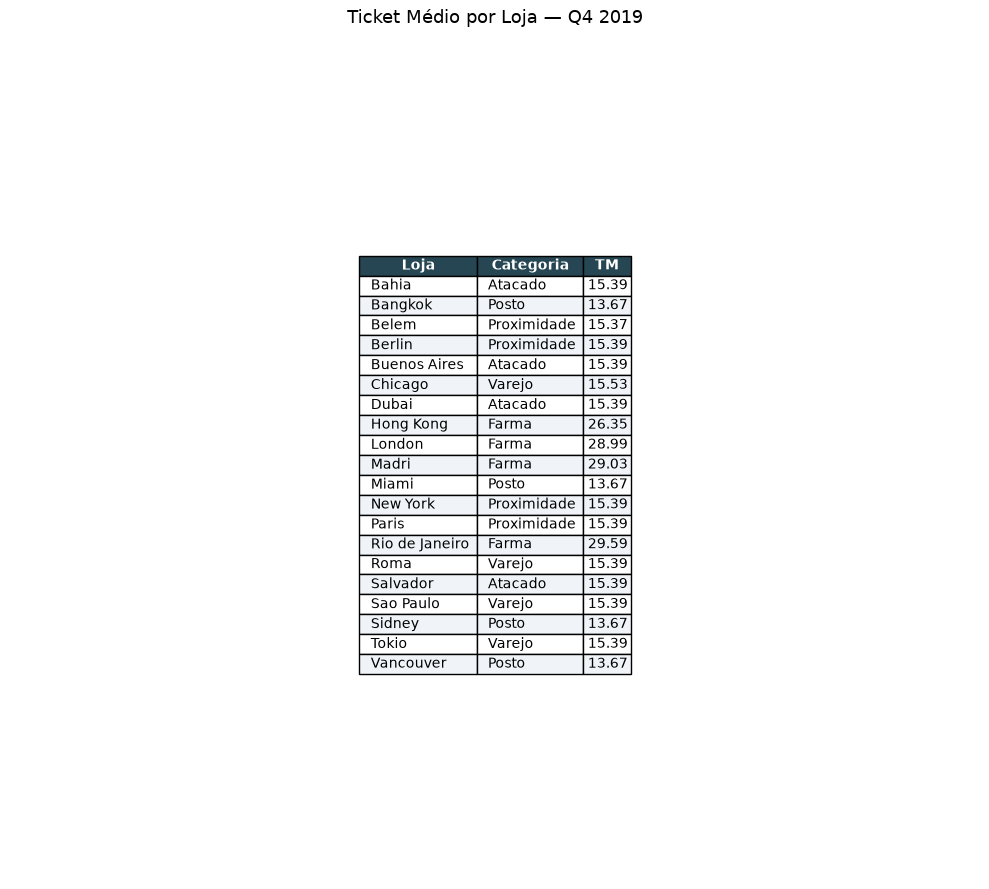

In [15]:
# RESPOSTA FINAL 


fig, ax = plt.subplots(figsize=(10, len(base) * 0.4 + 1))
ax.axis("off")

table = ax.table(
    cellText=base[["STORE_NAME", "BUSINESS_NAME", "TM"]].values,
    colLabels=["Loja", "Categoria", "TM"],
    cellLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width([0, 1, 2])

for j in range(3):
    table[0, j].set_facecolor("#264653")
    table[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(base) + 1):
    cor = "#f0f4f8" if i % 2 == 0 else "white"
    for j in range(3):
        table[i, j].set_facecolor(cor)

plt.title("Ticket Médio por Loja — Q4 2019", fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("tabela_tm.png", dpi=150, bbox_inches="tight")
plt.show()


## Decisões técnicas

- Separação entre etapa de preparação dos dados e cálculo dos indicadores — evita misturar transformação com regra de negócio
- Agregações feitas com operações vetorizadas do Pandas (`groupby`/`agg`) para reduzir custo de processamento em grandes volumes
- Ticket médio calculado após a consolidação dos dados — `SALES_VALUE / SALES_QTY` evita média incorreta por linha
- Datas normalizadas para `datetime` antes dos filtros e agrupamentos
- Agrupamento por dimensões de negócio (`STORE_CODE`, `STORE_NAME`, `BUSINESS_NAME`) para manter rastreabilidade do resultado
- Tratamento da base final focado em métricas de negócio, mantendo apenas colunas necessárias para resposta
- IA utilizada para: revisão da lógica de agregação e validação dos cálculos de indicadores